In [5]:
from mobslim.animate import animate_events
from mobslim.entities.agents import load_plans_from_xml
from mobslim.entities.networks import Networks
from mobslim.expected import SimpleExpectedDurations
from mobslim.listener import EventListener
from mobslim.optimizer import Optimizer
from mobslim.planners.greedy_trip_planner import GreedyTripPlanner
from mobslim.planners.rerouters.simple_rerouter import StaticRouter
from mobslim.sim import Sim

In [6]:
# network setup
network = Networks()
network.load_xml("../scenarios/equil/network.xml")

# agent setup
plans = load_plans_from_xml("../scenarios/equil/plans100.xml", networks=network)

# planner setup
expected_link_durations = SimpleExpectedDurations(network, network_mode="road")
router = StaticRouter(
    network=network, network_mode="road", expectations=expected_link_durations
)
planner = GreedyTripPlanner(plans=plans, router=router, network=network, p=0.2)

# initiate all plans with naive trip estimates
planner.plan()

# simulation setup
sim = Sim(networks=network, listener=EventListener())

# optimizer setup and run
optimizer = Optimizer(sim=sim, plans=plans, planner=planner)
events = optimizer.run(max_runs=20)

Plan([SOS(), Act(ActivityType.HOME, loc=2, dur=21600), Trip(None, 2>13, duration=None, route=None), Act(ActivityType.WORK, loc=13, dur=600), Trip(None, 13>13, duration=None, route=None), Act(ActivityType.WORK, loc=13, dur=12600), Trip(None, 13>2, duration=None, route=None), Act(ActivityType.HOME, loc=2, dur=None)])
['2', '3', '12', '13']
['13']
['13', '14', '15', '1', '2']
Plan([SOS(), Act(ActivityType.HOME, loc=2, dur=21540), Trip(None, 2>13, duration=None, route=None), Act(ActivityType.WORK, loc=13, dur=9000), Trip(None, 13>2, duration=None, route=None), Act(ActivityType.HOME, loc=2, dur=None)])
['2', '3', '12', '13']
['13', '14', '15', '1', '2']
Plan([SOS(), Act(ActivityType.HOME, loc=2, dur=21510), Trip(None, 2>13, duration=None, route=None), Act(ActivityType.WORK, loc=13, dur=5400), Trip(None, 13>2, duration=None, route=None), Act(ActivityType.HOME, loc=2, dur=None)])
['2', '3', '12', '13']
['13', '14', '15', '1', '2']
Plan([SOS(), Act(ActivityType.HOME, loc=2, dur=21570), Trip(No

KeyError: (None, '2', '3')

Building traces...
Animating traces...


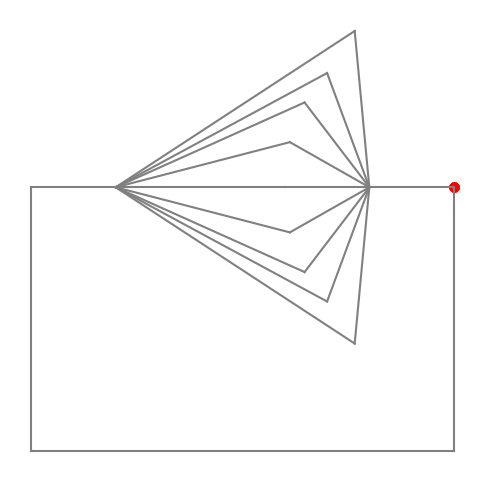

In [ ]:
start, limit, step = 21500, 22600, 100
ani = animate_events(network, events, start=start, limit=limit, step=step)
ani